# Data gathering

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
# Our obj. is to predict sales based of off these three factors

# Data cleaning

In [4]:
# Check for missing values
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


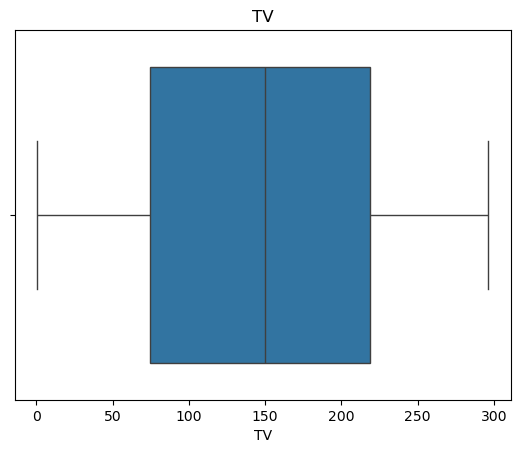

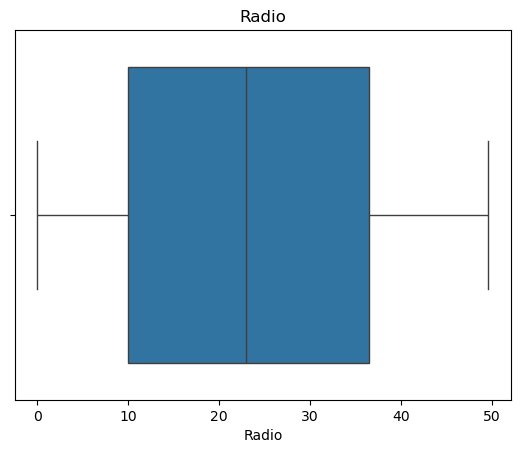

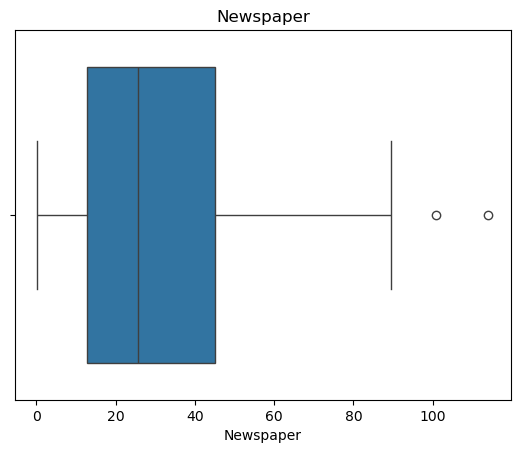

In [7]:
# Boxplot is used to check for outliers
# We're looking for which features to keep/remove for our model
cols = df.columns
# The above is of the type index

for x in cols:
    if x != 'Sales':
        # Orient the plot in a specific way -- h for horizontal and v for vertical
        sns.boxplot(df[x],orient='h')
        plt.title(x)
        plt.show()

# All charts should have titles
# x-axis 
# Those two dots in the newspaper plot represent outliers
# We'll leave our outliers since they aren't extreme. 

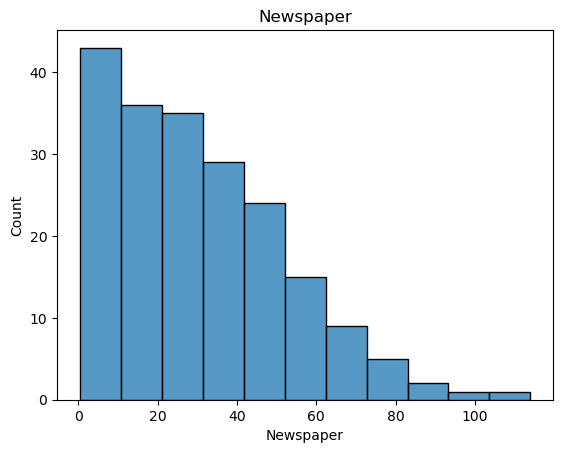

In [8]:
sns.histplot(df['Newspaper'])
plt.title('Newspaper')
plt.show()

Text(0.5, 1.0, 'Newspaper correlation')

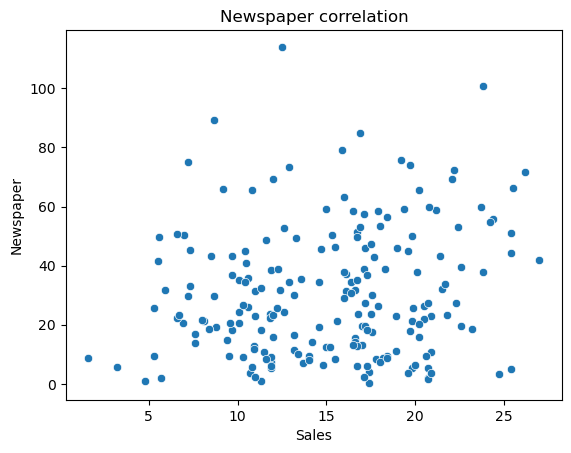

In [9]:
# Scatterplot or 
# To check correlation
sns.scatterplot(x=df['Sales'],y=df['Newspaper'])
plt.title('Newspaper correlation')

Text(0.5, 1.0, 'Radio correlation')

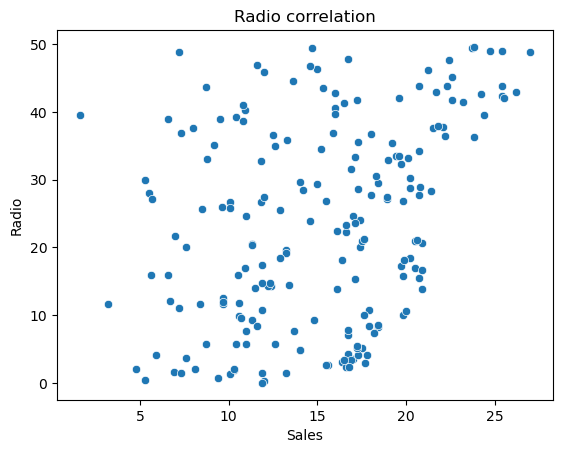

In [10]:
# Scatterplot or 
# To check correlation
sns.scatterplot(x=df['Sales'],y=df['Radio'])
plt.title('Radio correlation')

Text(0.5, 1.0, 'TV correlation')

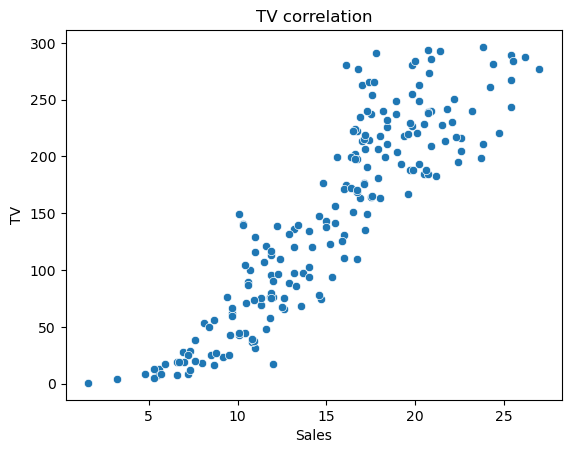

In [11]:
# Scatterplot or 
# To check correlation
sns.scatterplot(x=df['Sales'],y=df['TV'])
plt.title('TV correlation')

In [12]:
# Correlation matrix of our df
corr = df.corr()
corr
# Correlation: comparison of two variables 
# Ranges from -1 to +1
# Our goal is to compare sales and each of the vars using their correlation score -- 

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


# ML

In [15]:
# Imports a module for splitting our dataset
from sklearn.model_selection import train_test_split
# Sklearn contains 90% of the models we'll be using

In [41]:
# y always rep. your target variable
y = df['Sales']
# X reps the input features for your model
X = df.drop(axis=1,columns=['Sales','Newspaper'])

# This order has to be maintained coz its a tuple thus position matters
# Chooose proportion to split dataset b/w test and train
# We are doing random first
# random_state is to lock the lvl of randomness of our dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [42]:
# Ensuring the splitting is done correctly
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(140, 2) (140,) (60, 2) (60,)


In [43]:
# Import linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Evaluation

In [44]:
# Evaluation using test
# Bringing out the predicted values
y_pred = model.predict(X_test)
y_pred

array([17.01285904, 20.4488705 , 23.60910271,  9.45026723, 21.92223784,
       12.64670303, 21.19129751,  8.80828361, 17.17701441, 16.67602143,
        9.20140739,  8.51213112, 17.82568974,  8.36681175, 12.59429426,
       14.8473323 ,  8.27691446, 17.9674605 , 11.09142251, 20.54854911,
       20.63638154, 12.4258027 , 11.22240255, 22.23105478,  9.58184391,
        7.97322151, 20.91850836, 13.904554  , 10.82386432,  8.24000724,
       15.88021438, 10.78571053, 20.81760618, 10.45344608, 21.42102324,
       21.31584602, 12.48833692, 22.64371818, 12.74108951,  6.53676139,
       11.93104264, 15.37167328, 10.04699258,  9.57421162, 17.15625888,
        7.334098  , 10.38137537, 15.33481955, 11.10683243, 11.91205364,
       14.06995575, 14.6762636 , 10.56780797,  9.45425162,  9.07304284,
       12.4363488 , 10.63801284, 24.92898309,  8.08406547, 15.85815111])

In [45]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [46]:
r2 = r2_score(y_test, y_pred)
r2

0.9139189919346897

In [47]:
mse = mean_squared_error(y_test, y_pred)
mse

2.4081649798649596

In [48]:
rmse = root_mean_squared_error(y_test, y_pred)
rmse

1.5518263368898466

In [50]:
# Check the rule of thumb
# Rule of thumb
# 20% of Max y value
print(rmse < 0.2 * max(y))

True


# Assumptions for a Linear Regression Model

## Linearity

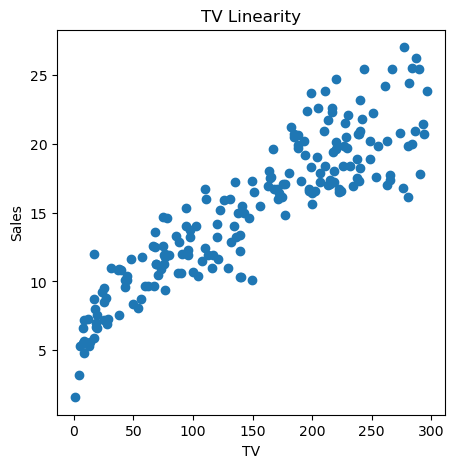

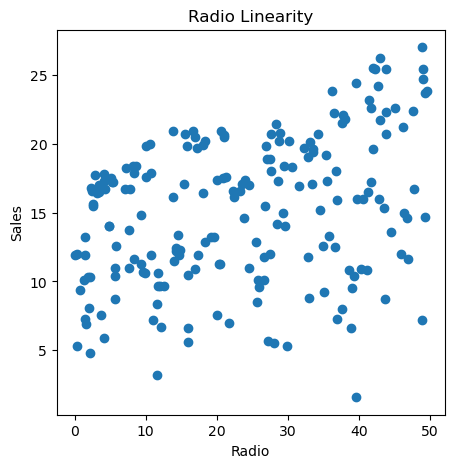

In [56]:
for i in X_test:
    plt.figure(figsize=(5,5))
    plt.title(f'{i} Linearity')
    plt.xlabel(i)
    plt.ylabel('Sales')
    plt.scatter(X[i],y)

## Homoscedasticity

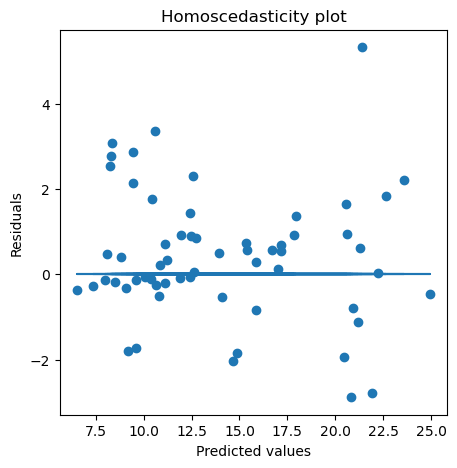

In [60]:
# Plot y_pred against residuals
residuals = y_pred - y_test
plt.figure(figsize=(5,5))
plt.title('Homoscedasticity plot')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.scatter(y_pred, residuals)
plt.plot(y_pred, [0]*len(y_pred))

## Normality

<Axes: title={'center': 'Normality Test'}, xlabel='Residuals', ylabel='Frequency'>

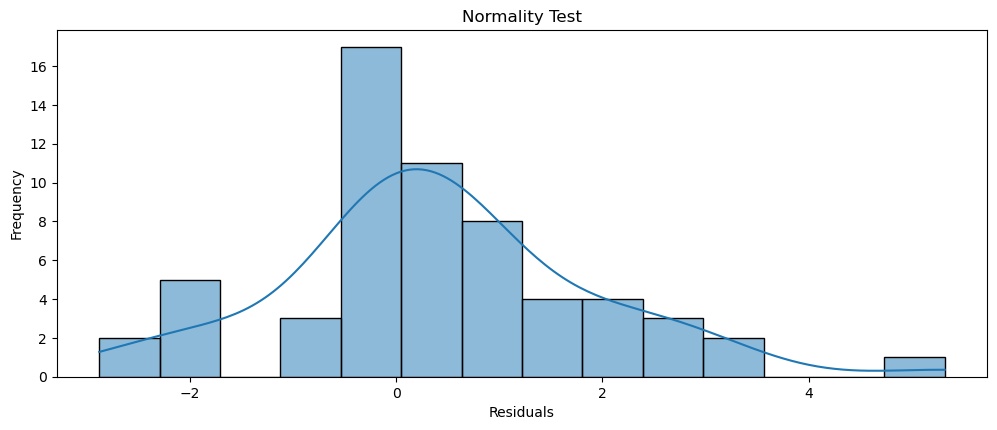

In [63]:
plt.figure(figsize=(12,4.5))
plt.title('Normality Test')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
sns.histplot(residuals, kde=True)

## Multicollinearity

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [67]:
vif = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
pd.DataFrame({'vif' : vif[0:]}, index=X_train.columns).T

,TV,Radio
vif,2.419362,2.419362
